In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
file_path = "combined.csv"   
df = pd.read_csv(file_path)

print("First 5 rows:")
print(df.head())
print("\nShape of dataset:")
print(df.shape)

First 5 rows:
   age  sex  chest pain type  resting bp s  cholesterol  fasting blood sugar  \
0   52    1                1         125.0        212.0                    0   
1   53    1                1         140.0        203.0                    1   
2   70    1                1         145.0        174.0                    0   
3   61    1                1         148.0        203.0                    0   
4   62    0                1         138.0        294.0                    1   

   resting ecg  max heart rate  exercise angina  oldpeak  ST slope  target  
0            1             168                0      1.0         2       0  
1            0             155                1      3.1         0       0  
2            1             125                1      2.6         0       0  
3            1             161                0      0.0         2       0  
4            1             106                0      1.9         1       0  

Shape of dataset:
(1220, 12)


In [3]:
df["ST slope"] = df["ST slope"].replace(0, np.nan)

In [4]:
df.isna().sum()

age                      0
sex                      0
chest pain type          0
resting bp s             1
cholesterol            172
fasting blood sugar      0
resting ecg              0
max heart rate           0
exercise angina          0
oldpeak                  0
ST slope                22
target                   0
dtype: int64

In [5]:
df['cholesterol'] = df.groupby('target')['cholesterol'].transform( lambda x: x.fillna(int (x.mean())) )

In [6]:
bp_index = df[df['resting bp s'].isna()].index

df.drop(bp_index, inplace=True)

In [7]:
df["ST slope"] = df["ST slope"].fillna(df["ST slope"].mode()[0])

In [8]:
df.isna().sum()

age                    0
sex                    0
chest pain type        0
resting bp s           0
cholesterol            0
fasting blood sugar    0
resting ecg            0
max heart rate         0
exercise angina        0
oldpeak                0
ST slope               0
target                 0
dtype: int64

In [9]:
X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [11]:
param_grid = {
    "rf__n_estimators": [100, 200, 300, 400],
    "rf__max_depth": [None, 5, 10, 20],
    "rf__min_samples_split": [2, 5, 10],
    "rf__min_samples_leaf": [1, 2, 4],
    "rf__max_features": ["sqrt", "log2", None],
    "rf__class_weight": [None, "balanced"]
}

In [12]:
pipeline = Pipeline([ ("rf", RandomForestClassifier(random_state=42)) ])

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)


In [13]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 864 candidates, totalling 4320 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'rf__class_weight': [None, 'balanced'], 'rf__max_depth': [None, 5, ...], 'rf__max_features': ['sqrt', 'log2', ...], 'rf__min_samples_leaf': [1, 2, ...], ...}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,300


In [14]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Score:")
print(grid_search.best_score_)

Best Parameters:
{'rf__class_weight': None, 'rf__max_depth': None, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 2, 'rf__n_estimators': 300}

Best Cross-Validation Score:
0.8317948717948719


In [15]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

In [16]:
print("\nTest Accuracy:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Test Accuracy:
0.7663934426229508

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.74      0.73       106
           1       0.80      0.79      0.79       138

    accuracy                           0.77       244
   macro avg       0.76      0.76      0.76       244
weighted avg       0.77      0.77      0.77       244


Confusion Matrix:
[[ 78  28]
 [ 29 109]]


In [17]:
feature_names = df.drop("target", axis=1).columns
rf_model = best_model.named_steps["rf"]

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

print(feature_importance)

                feature  importance
10             ST slope    0.228654
2       chest pain type    0.145414
4           cholesterol    0.127920
7        max heart rate    0.110767
0                   age    0.091090
3          resting bp s    0.087666
9               oldpeak    0.086530
6           resting ecg    0.041708
8       exercise angina    0.033700
1                   sex    0.025418
5   fasting blood sugar    0.021133


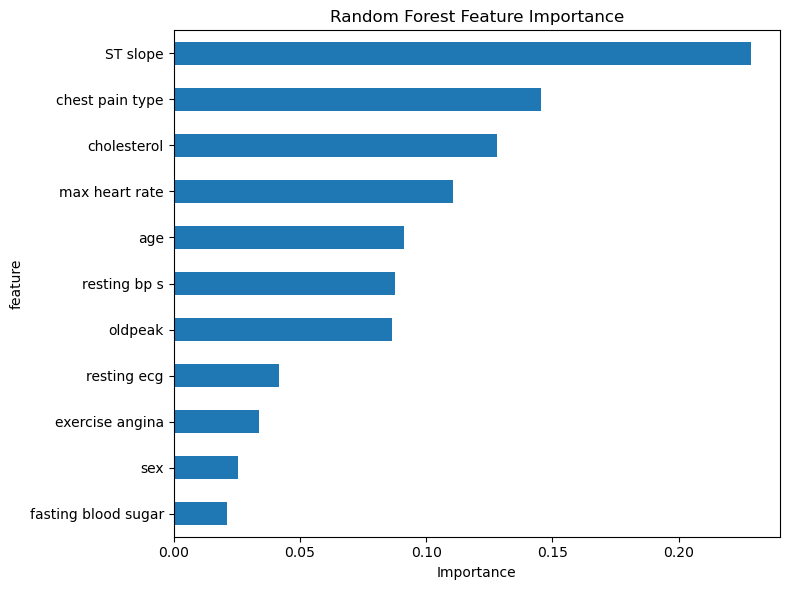

In [18]:
feature_importance.plot(
    x="feature",
    y="importance",
    kind="barh",
    figsize=(8, 6),
    legend=False
)

plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.savefig("Feature importance_random forest.png", dpi=300)
plt.show()